# Analisis Sentimen Berbasis Aspek (ABSA) Murni - TNGC
**Studi Kasus:** 12 Objek Daya Tarik Wisata Alam (ODTWA) & Jalur Pendakian Resmi Balai Taman Nasional Gunung Ciremai.

### Alur Kerja Ilmiah (Zero Data Leakage Pipeline):
1. **Ingesti Data Multi-Target**: Memuat 2.216 ulasan asli Google Maps dari 12 POI resmi TNGC.
2. **Audit & Visualisasi Pipeline Cleaning**: Membandingkan volume data mentah (raw), hasil eliminasi estetika alam murni, dan rasio ulasan fasilitas per destinasi.
3. **Normalisasi Leksikon Akademik**: Menggunakan *Colloquial Indonesian Lexicon* (Fasilkom UI) ditambah dialek Sunda & istilah pendakian.
4. **Peta Teks Leksikal (Word Cloud)**: Memvisualisasikan klaster kata keluhan vs kata apresiasi pengunjung.
5. **Train-Test Stratified Split (80:20)**: Menjamin data testing terisolasi.
6. **Ekstraksi Fitur TF-IDF & Penanganan Imbalance (SMOTE)**: Diterapkan hanya pada data latih.
7. **Komparasi Model Klasifikasi Tradisional**: Linear SVM, Logistic Regression, dan Random Forest.
8. **Deep Learning Fine-Tuning IndoBERT (`indobenchmark/indobert-base-p1`)**: Menggunakan PyTorch dengan akselerasi GPU NVIDIA RTX 3050 Laptop.
9. **Evaluasi Komparatif & Visualisasi**: Macro F1-score, Confusion Matrix Heatmap, dan sebaran komplain per POI.
10. **Output Raw ABSA Murni (Siap Terintegrasi API LLM)**: Menghasilkan struktur JSON standar yang siap dikonsumsi langsung oleh API LLM untuk menghasilkan rekomendasi generatif.

import os
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

# Resolusi path direktori root dan core module
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'ml-notebooks' else os.getcwd()
CORE_DIR = os.path.join(ROOT_DIR, 'core')
if CORE_DIR not in sys.path:
    sys.path.insert(0, CORE_DIR)
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

from tngc_analytics_core import (
    filter_facility_reviews,
    preprocess_corpus,
    train_benchmark_models,
    ASPECT_LEXICON
)
from pure_absa import generate_pure_absa_payload, format_llm_prompt_template
from lexicon_loader import SLANG_DICTIONARY, normalize_text_github
from indobert_trainer import train_indobert, DEVICE

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
RANDOM_SEED = 42

print(f'Device Komputasi PyTorch: {DEVICE}')
if torch.cuda.is_available():
    print(f'Akselerator GPU: {torch.cuda.get_device_name(0)}')


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split

from tngc_analytics_core import (
    filter_facility_reviews,
    preprocess_corpus,
    train_benchmark_models,
    ASPECT_LEXICON
)
from pure_absa import generate_pure_absa_payload, format_llm_prompt_template
from lexicon_loader import SLANG_DICTIONARY, normalize_text_github
from indobert_trainer import train_indobert, DEVICE

# Konfigurasi visualisasi ilmiah
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8
RANDOM_SEED = 42

print(f"Device Komputasi PyTorch: {DEVICE}")
if torch.cuda.is_available():
    print(f"Akselerator GPU: {torch.cuda.get_device_name(0)}")

c:\Users\seeva\.venvs\nlp-env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device Komputasi PyTorch: cuda
Akselerator GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


DATA_PATH = os.path.join(ROOT_DIR, 'data', 'raw', 'tngc_official_multitarget_reviews.csv')
df_raw = pd.read_csv(DATA_PATH)
print(f'Total baris ulasan terverifikasi: {len(df_raw)} ulasan dari {df_raw["poi_name"].nunique()} destinasi')
df_raw.head(3)


In [2]:
DATA_PATH = "tngc_official_multitarget_reviews.csv"
df_raw = pd.read_csv(DATA_PATH)
print(f"Total baris ulasan terverifikasi: {len(df_raw)} ulasan dari {df_raw['poi_name'].nunique()} destinasi")
df_raw.head(3)

Total baris ulasan terverifikasi: 2216 ulasan dari 12 destinasi


,review_id,poi_name,category,rating,review_text,published_at,sentiment
0,1,Taman Nasional Gunung Ciremai (Pusat Balai TNGC),Pusat Balai TNGC,1,Untuk fasilitas basecamp Palutungan mohon dipe...,NaN,negatif
1,2,Taman Nasional Gunung Ciremai (Pusat Balai TNGC),Pusat Balai TNGC,1,Sudah banyak yg tidak berpungsi pasilitasnya ....,NaN,negatif
2,3,Taman Nasional Gunung Ciremai (Pusat Balai TNGC),Pusat Balai TNGC,1,Seru macul di taman nasional gunung Ciremai,NaN,negatif


## 3. Grafik Audit Komparasi Cleaning per Destinasi / POI

c:\Users\seeva\gemilang\rnd\analysis-TNGC\tngc_analytics_core.py:63: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df["review_text"].str.contains(FACILITY_REGEX_FILTER, na=False)


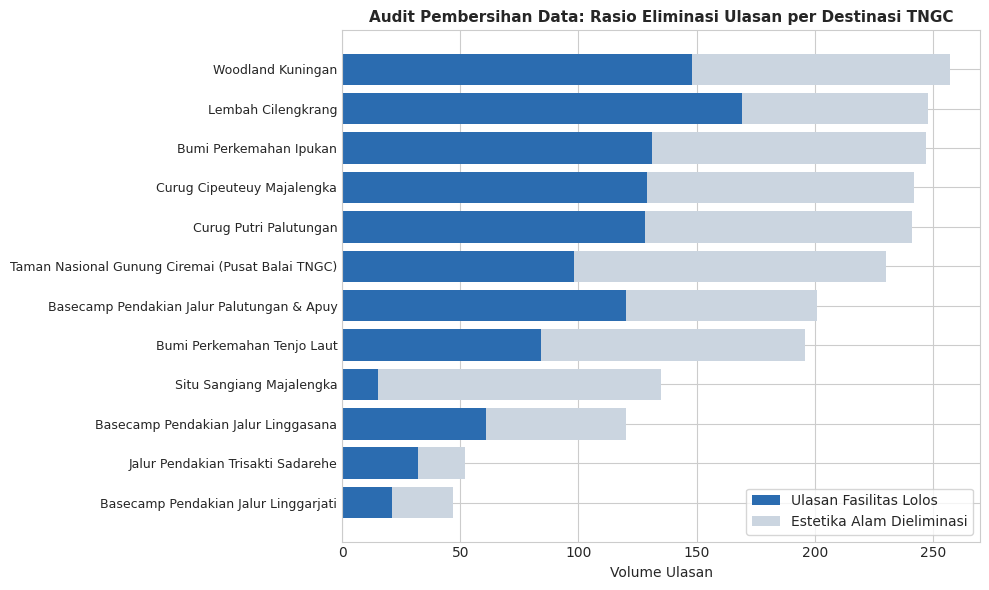

,Destinasi,Total Raw,Estetika Alam (Dieliminasi),Fasilitas & Operasional,Rasio Lolos (%)
0,Woodland Kuningan,257,109,148,57.59
1,Lembah Cilengkrang,248,79,169,68.15
2,Bumi Perkemahan Ipukan,247,116,131,53.04
3,Curug Cipeuteuy Majalengka,242,113,129,53.31
4,Curug Putri Palutungan,241,113,128,53.11
5,Taman Nasional Gunung Ciremai (Pusat Balai TNGC),230,132,98,42.61
6,Basecamp Pendakian Jalur Palutungan & Apuy,201,81,120,59.70
7,Bumi Perkemahan Tenjo Laut,196,112,84,42.86
8,Situ Sangiang Majalengka,135,120,15,11.11
9,Basecamp Pendakian Jalur Linggasana,120,59,61,50.83


In [3]:
audit_records = []
for poi, grp in df_raw.groupby("poi_name"):
    total_raw = len(grp)
    fac, _ = filter_facility_reviews(grp)
    total_fac = len(fac)
    total_nature = total_raw - total_fac
    audit_records.append({
        "Destinasi": poi,
        "Total Raw": total_raw,
        "Estetika Alam (Dieliminasi)": total_nature,
        "Fasilitas & Operasional": total_fac,
        "Rasio Lolos (%)": round((total_fac / total_raw * 100), 2)
    })

df_audit = pd.DataFrame(audit_records).sort_values(by="Total Raw", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=100)
y_pos = np.arange(len(df_audit))
p1 = ax.barh(y_pos, df_audit["Fasilitas & Operasional"], color="#2b6cb0", label="Ulasan Fasilitas Lolos")
p2 = ax.barh(y_pos, df_audit["Estetika Alam (Dieliminasi)"], left=df_audit["Fasilitas & Operasional"], color="#cbd5e0", label="Estetika Alam Dieliminasi")
ax.set_yticks(y_pos)
ax.set_yticklabels(df_audit["Destinasi"], fontsize=9)
ax.set_xlabel("Volume Ulasan", fontsize=10)
ax.set_title("Audit Pembersihan Data: Rasio Eliminasi Ulasan per Destinasi TNGC", fontsize=11, fontweight="bold")
ax.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

df_audit.sort_values(by="Total Raw", ascending=False).reset_index(drop=True)

## 4. Normalisasi Leksikon Akademik (Kamus Alay UI) & Ekstraksi Aspek

In [4]:
df_facility, _ = filter_facility_reviews(df_raw)
df_proc = preprocess_corpus(df_facility)
print(f"Total korpus fasilitas terproses: {len(df_proc)} ulasan")
df_proc[["poi_name", "rating", "sentiment", "review_text", "clean_text"]].head(3)

Total korpus fasilitas terproses: 1136 ulasan


c:\Users\seeva\gemilang\rnd\analysis-TNGC\tngc_analytics_core.py:63: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df["review_text"].str.contains(FACILITY_REGEX_FILTER, na=False)


,poi_name,rating,sentiment,review_text,clean_text
0,Taman Nasional Gunung Ciremai (Pusat Balai TNGC),1,negatif,Untuk fasilitas basecamp Palutungan mohon dipe...,untuk fasilitas pos registrasi palutungan moho...
1,Taman Nasional Gunung Ciremai (Pusat Balai TNGC),2,negatif,"Akses jalan yang kurang baik,..jauh dari kata ...",akses jalan yang kurang baik jauh dari kata la...
2,Taman Nasional Gunung Ciremai (Pusat Balai TNGC),3,netral,Konturnya tanjakan. Pos 1 sd Pos 2 relatif nya...,konturnya tanjakan pos 1 sd pos 2 relatif nyam...


## 5. Peta Teks Leksikal (Word Cloud: Keluhan vs Apresiasi Pengunjung)

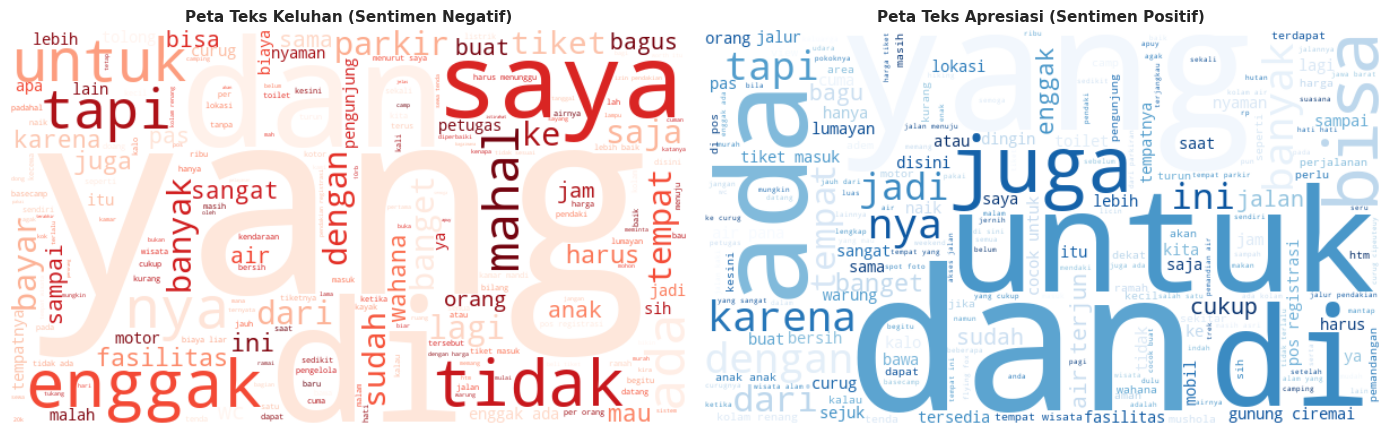

In [5]:
neg_corpus = " ".join(df_proc[df_proc["sentiment"] == "negatif"]["clean_text"].dropna())
pos_corpus = " ".join(df_proc[df_proc["sentiment"] == "positif"]["clean_text"].dropna())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

wc_neg = WordCloud(width=600, height=350, background_color="white", colormap="Reds", random_state=RANDOM_SEED).generate(neg_corpus)
axes[0].imshow(wc_neg, interpolation="bilinear")
axes[0].set_title("Peta Teks Keluhan (Sentimen Negatif)", fontsize=11, fontweight="bold")
axes[0].axis("off")

wc_pos = WordCloud(width=600, height=350, background_color="white", colormap="Blues", random_state=RANDOM_SEED).generate(pos_corpus)
axes[1].imshow(wc_pos, interpolation="bilinear")
axes[1].set_title("Peta Teks Apresiasi (Sentimen Positif)", fontsize=11, fontweight="bold")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. Train-Test Split (80:20), TF-IDF, dan Resampling SMOTE pada Data Latih

In [6]:
X = df_proc["clean_text"]
y = df_proc["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

benchmark = train_benchmark_models(X_train, y_train, X_test, y_test, random_state=RANDOM_SEED)

print(f"Dimensi Fitur Training Setelah SMOTE: {benchmark['X_train_res_shape']}")
print(f"Distribusi Kelas Data Latih Setelah SMOTE: {benchmark['y_train_res_dist']}")

Dimensi Fitur Training Setelah SMOTE: (2220, 2500)
Distribusi Kelas Data Latih Setelah SMOTE: {'positif': 740, 'negatif': 740, 'netral': 740}


## 7. Deep Learning Fine-Tuning: IndoBERT (`indobenchmark/indobert-base-p1`)

Mengeksekusi Fine-Tuning IndoBERT pada GPU CUDA...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Fine-Tuning Selesai. Macro F1-Score IndoBERT: 63.30%


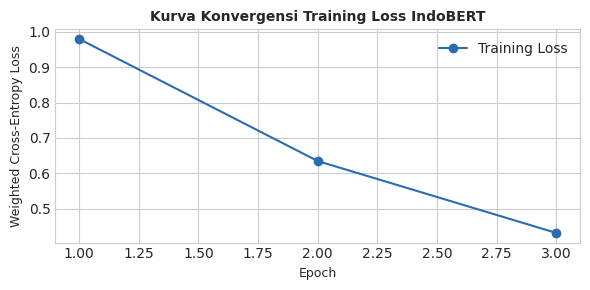

In [7]:
print("Mengeksekusi Fine-Tuning IndoBERT pada GPU CUDA...")
indobert_res = train_indobert(
    train_texts=X_train.tolist(),
    train_labels=y_train.tolist(),
    val_texts=X_test.tolist(),
    val_labels=y_test.tolist(),
    epochs=3,
    batch_size=16,
    lr=2e-5
)

print(f"Fine-Tuning Selesai. Macro F1-Score IndoBERT: {indobert_res['best_macro_f1']*100:.2f}%")

fig, ax = plt.subplots(figsize=(6, 3), dpi=100)
ax.plot(range(1, len(indobert_res['history']['train_loss'])+1), indobert_res['history']['train_loss'], marker='o', color='#2b6cb0', label='Training Loss')
ax.set_title("Kurva Konvergensi Training Loss IndoBERT", fontsize=10, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=9)
ax.set_ylabel("Weighted Cross-Entropy Loss", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Evaluasi Komparatif Komprehensif (Klasik vs Deep Learning IndoBERT)

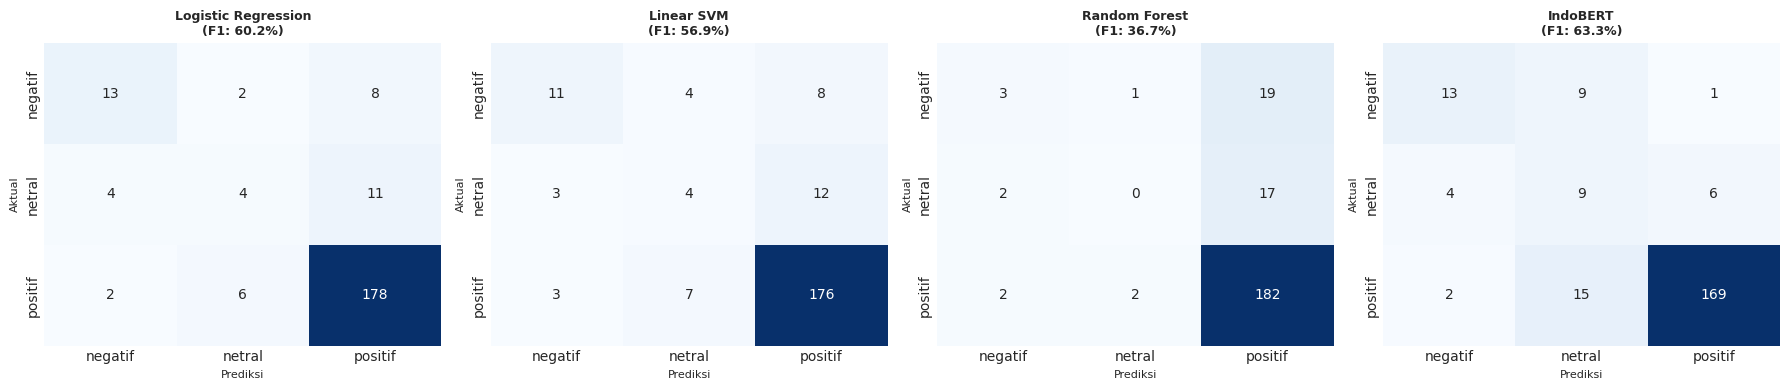

,Model,Macro Precision (%),Macro Recall (%),Macro F1-Score (%),Accuracy (%)
3,IndoBERT (indobenchmark/indobert-base-p1),63.91,64.92,63.30,83.77
0,Logistic Regression,64.04,57.76,60.22,85.53
1,Linear SVM,60.39,54.50,56.89,83.77
2,Random Forest,42.11,36.96,36.70,81.14


In [8]:
model_metrics = []
for name, data in benchmark["models"].items():
    rep = data["report"]
    model_metrics.append({
        "Model": name,
        "Macro Precision (%)": round(rep["macro avg"]["precision"] * 100, 2),
        "Macro Recall (%)": round(rep["macro avg"]["recall"] * 100, 2),
        "Macro F1-Score (%)": round(data["macro_f1"] * 100, 2),
        "Accuracy (%)": round(rep["accuracy"] * 100, 2)
    })

rep_bert = indobert_res["classification_report"]
model_metrics.append({
    "Model": "IndoBERT (indobenchmark/indobert-base-p1)",
    "Macro Precision (%)": round(rep_bert["macro avg"]["precision"] * 100, 2),
    "Macro Recall (%)": round(rep_bert["macro avg"]["recall"] * 100, 2),
    "Macro F1-Score (%)": round(indobert_res["best_macro_f1"] * 100, 2),
    "Accuracy (%)": round(rep_bert["accuracy"] * 100, 2)
})

metrics_df = pd.DataFrame(model_metrics).sort_values(by="Macro F1-Score (%)", ascending=False)

classes = benchmark["classes"]
fig, axes = plt.subplots(1, 4, figsize=(18, 4), dpi=100)

all_models_dict = {**benchmark["models"], "IndoBERT": indobert_res}
for ax, (name, data) in zip(axes, all_models_dict.items()):
    cm = data["confusion_matrix"]
    f1_val = data["best_macro_f1"] if "best_macro_f1" in data else data["macro_f1"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=classes, yticklabels=classes)
    ax.set_title(f"{name}\n(F1: {f1_val*100:.1f}%)", fontsize=9, fontweight='bold')
    ax.set_xlabel("Prediksi", fontsize=8)
    ax.set_ylabel("Aktual", fontsize=8)

plt.tight_layout()
plt.show()

metrics_df

# Contoh 3 sampel payload JSON murni dari ulasan keluhan
sample_complaints = df_proc[df_proc["sentiment"] == "negatif"].head(3)

for idx, row in sample_complaints.iterrows():
    payload = generate_pure_absa_payload(
        review_id=int(row["review_id"]),
        poi_name=str(row["poi_name"]),
        text=str(row["review_text"]),
        rating=int(row["rating"]),
        overall_sentiment=str(row["sentiment"])
    )
    print(f"\n==================== DESTINASI: {row['poi_name']} ====================")
    print(json.dumps(payload, indent=2, ensure_ascii=False))

# Ekspor seluruh dataset ke format JSON Payload untuk pipeline API LLM kamu
all_absa_payloads = []
for idx, row in df_proc.iterrows():
    p = generate_pure_absa_payload(
        review_id=int(row["review_id"]),
        poi_name=str(row["poi_name"]),
        text=str(row["review_text"]),
        rating=int(row["rating"]),
        overall_sentiment=str(row["sentiment"])
    )
    all_absa_payloads.append(p)

OUTPUT_JSON = os.path.join(ROOT_DIR, "data", "processed", "tngc_pure_absa_payloads.json")
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(all_absa_payloads, f, indent=2, ensure_ascii=False)

print(f"\nBerhasil mengekspor {len(all_absa_payloads)} data raw ABSA ke: {OUTPUT_JSON}")


In [9]:
# Contoh 3 sampel payload JSON murni dari ulasan keluhan
sample_complaints = df_proc[df_proc["sentiment"] == "negatif"].head(3)

for idx, row in sample_complaints.iterrows():
    payload = generate_pure_absa_payload(
        review_id=int(row["review_id"]),
        poi_name=str(row["poi_name"]),
        text=str(row["review_text"]),
        rating=int(row["rating"]),
        overall_sentiment=str(row["sentiment"])
    )
    print(f"\n==================== DESTINASI: {row['poi_name']} ====================")
    print(json.dumps(payload, indent=2, ensure_ascii=False))

# Ekspor seluruh dataset ke format JSON Payload untuk pipeline API LLM kamu
all_absa_payloads = []
for idx, row in df_proc.iterrows():
    p = generate_pure_absa_payload(
        review_id=int(row["review_id"]),
        poi_name=str(row["poi_name"]),
        text=str(row["review_text"]),
        rating=int(row["rating"]),
        overall_sentiment=str(row["sentiment"])
    )
    all_absa_payloads.append(p)

OUTPUT_JSON = "tngc_pure_absa_payloads.json"
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(all_absa_payloads, f, indent=2, ensure_ascii=False)

print(f"\nBerhasil mengekspor {len(all_absa_payloads)} data raw ABSA ke: {OUTPUT_JSON}")


==================== DESTINASI: Taman Nasional Gunung Ciremai (Pusat Balai TNGC) ====================
{
  "review_id": 1,
  "poi_name": "Taman Nasional Gunung Ciremai (Pusat Balai TNGC)",
  "review_text": "Untuk fasilitas basecamp Palutungan mohon diperbaiki. Saya bilang diperbaiki bukan ditingkatkan. Banyak fasilitas yg (menurut saya) gk layak pakai. Petugasnya memang ramah, baik pula. Tp untuk fasilitas, saya mikir² utk ngasih bintang lima. Saya kira cukup dan mohon perhatian dr pihak pengelola, tak perlu lagi saya berpanjang lebar merinci bagaimana kekurangannya, saya tdk keliru dr apa yg saya sdh sebutkan. Terima kasih",
  "rating": 1,
  "overall_sentiment": "negatif",
  "extracted_aspects": [
    {
      "aspect_category": "pelayanan_petugas",
      "detected_terms": [
        "ramah"
      ],
      "aspect_sentiment": "negatif",
      "confidence": 0.95
    }
  ],
  "aspect_count": 1,
  "needs_llm_intervention": true
}

==================== DESTINASI: Taman Nasional Gunung Cirem